In [ ]:
# If fastai not installed yet, run this first:
# pip install fastai

from fastai.vision.all import *
from pathlib import Path
import matplotlib.pyplot as plt

Classes: ['lie', 'truth']
Training samples: 16
Validation samples: 4


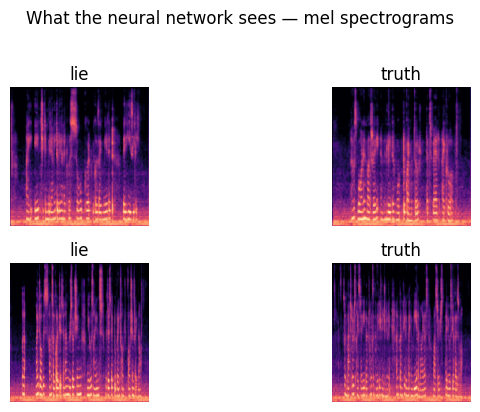

In [ ]:
DATA_DIR = Path("../data")

# Fast.ai reads folder names as labels automatically
# data/truth/ → label "truth"
# data/lie/   → label "lie"

dls = ImageDataLoaders.from_folder(
    DATA_DIR,
    valid_pct=0.2,        # 20% held out as validation set — never seen during training
    seed=42,              # same split every run — reproducible
    item_tfms=Resize(224), # resize all spectrograms to 224x224 — ResNet expects this
    bs=4                 # batch size of 4 — small dataset, so small batches to avoid overfitting
)

# Verify it loaded correctly
print(f"Classes: {dls.vocab}")
print(f"Training samples: {len(dls.train_ds)}")
print(f"Validation samples: {len(dls.valid_ds)}")

# Show a batch so you can see what the model will see
dls.show_batch(max_n=6, figsize=(8, 4))
plt.suptitle("What the neural network sees — mel spectrograms", y=1.02)
plt.tight_layout()
plt.show()

In [6]:
# ResNet18 — a proven image classification architecture
# fine_tune() = use pretrained ImageNet weights, then adapt to our data
# This is transfer learning — the model already knows how to read images
# We are teaching it to read spectrograms specifically

learn = vision_learner(dls, resnet18, metrics=error_rate)

print("Starting training — watch the valid_loss column closely")
print("If valid_loss goes UP while train_loss goes DOWN = overfitting\n")

learn.fine_tune(10)  # 10 epochs — enough to see the curve on 20 samples

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\PRAGADESH/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:13<00:00, 3.57MB/s]


Starting training — watch the valid_loss column closely
If valid_loss goes UP while train_loss goes DOWN = overfitting



epoch,train_loss,valid_loss,error_rate,time
0,1.270332,2.762426,0.750000,00:01


epoch,train_loss,valid_loss,error_rate,time
0,0.929544,1.763848,0.750000,00:01
1,0.711910,1.587329,0.750000,00:02
2,0.698963,1.027539,0.750000,00:01
3,0.549934,1.331101,0.750000,00:01
4,0.594981,1.594463,0.750000,00:01
5,0.525856,1.609435,0.750000,00:01
6,0.545047,1.951388,0.750000,00:01
7,0.596527,2.064295,0.750000,00:01
8,0.511466,2.067911,0.750000,00:01
9,0.519599,2.065692,0.750000,00:01


In [ ]:
# This is the most important chart you will generate this week
# It shows exactly what you learned about overfitting in Week 1

learn.recorder.plot_loss()
plt.title("Training loss vs Validation loss\n(Watch for the gap — that is overfitting)")
plt.tight_layout()
plt.show()

: 

In [ ]:
# Get final training and validation metrics
results = learn.validate()
print(f"\nFinal validation error rate: {results[1]:.4f}")
print(f"Final validation accuracy: {(1 - results[1])*100:.1f}%")

# Show what it got wrong
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(4, 4))
plt.title("Confusion Matrix — what the model got wrong")
plt.show()

# Show the highest loss predictions — where the model was most wrong
interp.plot_top_losses(6, figsize=(8, 4))
plt.show()

: 

In [ ]:
learn.export('../models/voice_truth_analyser_v1.pkl')
print("Model saved to models/voice_truth_analyser_v1.pkl")
print("This is your v1 — trained on 20 samples, baseline only")